# Resumo Executivo

**Projeto:** Social Wave — Otimização de Campanhas de Marketing  
**Fase:** Entrega (Fase 4)  
**Objetivo:** Consolidar todos os insights em formato de apresentação para gestores

---

## Este notebook consolida

| Origem | Conteúdo |
|--------|----------|
| Notebook 01 | Diagnóstico: onde está o problema |
| Notebook 02 | Análise: por que cada canal é caro |
| Notebook 03 | Recomendação: como otimizar o orçamento |

---

## Entregáveis
- Storytelling executivo (narrativa para gestores)
- Métricas consolidadas (antes/depois)
- Plano de ação com cronograma

## Setup e Carregamento dos Resumos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURAÇÕES VISUAIS
# ============================================================

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ============================================================
# CARREGAR DADOS
# ============================================================

print('=' * 60)
print('📊 CARREGAMENTO DOS RESUMOS')
print('=' * 60)

# Base processada
df = pd.read_pickle(r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\campanhas_base_processada.pkl')
resumo = pd.read_pickle(r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_por_canal.pkl')

print(f'\n✅ Base: {df.shape[0]:,} registros x {df.shape[1]} colunas')
print(f'✅ Resumo por canal: {len(resumo)} canais')

# ============================================================
# RECONSTRUIR VARIÁVEIS DO NOTEBOOK 03
# ============================================================

print('\n' + '-' * 60)
print('RECONSTRUINDO VARIÁVEIS DA OTIMIZAÇÃO')
print('-' * 60)

# Dados por canal
canais = resumo.index.tolist()
n_canais = len(canais)

gasto_total = resumo['Gasto_Total'].sum()
conversao_total = resumo['Conversao_Total'].sum()
cpa_global = gasto_total / conversao_total

cpa_atual = resumo['CPA'].values
conversoes_atual = resumo['Conversao_Total'].values
share_atual = resumo['Share_Gasto'].values / 100

# Canal mais e menos eficiente
canal_top = resumo['CPA'].idxmin()
canal_bottom = resumo['CPA'].idxmax()
cpa_top = resumo.loc[canal_top, 'CPA']
cpa_bottom = resumo.loc[canal_bottom, 'CPA']

# Canal maior gasto e maior conversao
canal_maior_gasto = resumo['Share_Gasto'].idxmax()
canal_maior_conv = resumo['Share_Conversao'].idxmax()

print(f'✅ Canais: {n_canais}')
print(f'✅ Shares atuais reconstruídos')

# ============================================================
# RECALCULAR OTIMIZAÇÃO (SIMPLIFICADA)
# ============================================================

print('\n' + '-' * 60)
print('RECALCULANDO ALOCAÇÃO ÓTIMA')
print('-' * 60)

from scipy.optimize import minimize

def calcular_cpa_global(share, cpa_base, gasto_total, elasticidade=0.3):
    share_base = share_atual
    ratio = share / share_base
    ratio = np.maximum(ratio, 0.01)
    cpa_ajustado = cpa_base * (1 + elasticidade * np.log(ratio))
    cpa_ajustado = np.maximum(cpa_ajustado, cpa_base * 0.5)
    gasto_canal = share * gasto_total
    conversoes_canal = gasto_canal / cpa_ajustado
    conversoes_total = conversoes_canal.sum()
    if conversoes_total > 0:
        return gasto_total / conversoes_total
    return float('inf')

def objetivo(share):
    return calcular_cpa_global(share, cpa_atual, gasto_total)

def restricao_soma(share):
    return share.sum() - 1.0

bounds = [(0.05, 0.50) for _ in range(n_canais)]
restricoes = {'type': 'eq', 'fun': restricao_soma}

x0 = share_atual.copy()
x0 = np.maximum(x0, 0.05)
x0 = np.minimum(x0, 0.50)
x0 = x0 / x0.sum()

resultado = minimize(
    objetivo,
    x0,
    method='SLSQP',
    bounds=bounds,
    constraints=restricoes,
    options={'ftol': 1e-9, 'disp': False, 'maxiter': 1000}
)

if resultado.success:
    share_otimo = resultado.x
    cpa_global_otimo = calcular_cpa_global(share_otimo, cpa_atual, gasto_total)
    
    # Recalcular conversoes otimizadas
    ratio = share_otimo / share_atual
    ratio = np.maximum(ratio, 0.01)
    cpa_aj_otimo = cpa_atual * (1 + 0.3 * np.log(ratio))
    cpa_aj_otimo = np.maximum(cpa_aj_otimo, cpa_atual * 0.5)
    gasto_canal_ot = share_otimo * gasto_total
    conv_otimo = gasto_canal_ot / cpa_aj_otimo
    conversoes_total_otimo = conv_otimo.sum()
    
    print(f'✅ Otimização concluída')
    print(f'   CPA ótimo: ${cpa_global_otimo:.2f}')
else:
    print(f'⚠️ Otimização falhou, usando atual como fallback')
    share_otimo = share_atual.copy()
    cpa_global_otimo = cpa_global
    conversoes_total_otimo = conversao_total

# ============================================================
# RESUMOS DE TEXTO
# ============================================================

print('\n' + '-' * 60)
print('CARREGANDO RESUMOS DE TEXTO')
print('-' * 60)

resumos = {}
arquivos = {
    'EDA': r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_executivo_eda.txt',
    'CPA': r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_analise_cpa.txt',
    'Otimizacao': r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_otimizacao.txt'
}

for nome, path in arquivos.items():
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            resumos[nome] = f.read()
        print(f'✅ Resumo {nome}: carregado')
    else:
        print(f'⚠️ Resumo {nome}: nao encontrado')

# ============================================================
# MÉTRICAS CHAVE
# ============================================================

print('\n' + '-' * 60)
print('MÉTRICAS CHAVE CONSOLIDADAS')
print('-' * 60)

print(f'\n📊 Contexto:')
print(f'   Período: Out-Dez 2023')
print(f'   Gasto total: ${gasto_total:,.2f}')
print(f'   Conversões: {conversao_total:,.0f}')
print(f'   CPA global: ${cpa_global:.2f}')

print(f'\n🏆 Eficiência:')
print(f'   Melhor canal: {canal_top} (CPA ${cpa_top:.2f})')
print(f'   Pior canal: {canal_bottom} (CPA ${cpa_bottom:.2f})')
print(f'   Diferença: {cpa_bottom/cpa_top:.1f}x mais caro')

print(f'\n📊 Desbalanceamento:')
print(f'   Maior investimento: {canal_maior_gasto} ({resumo.loc[canal_maior_gasto, 'Share_Gasto']:.1f}% do gasto)')
print(f'   Maior retorno: {canal_maior_conv} ({resumo.loc[canal_maior_conv, 'Share_Conversao']:.1f}% das conversões)')

print(f'\n🎯 Otimização:')
print(f'   CPA atual: ${cpa_global:.2f}')
print(f'   CPA ótimo: ${cpa_global_otimo:.2f}')
print(f'   Redução: {((cpa_global - cpa_global_otimo) / cpa_global * 100):.1f}%')

print('\n' + '=' * 60)
print('🚀 DADOS CARREGADOS!')
print('=' * 60)

📊 CARREGAMENTO DOS RESUMOS

✅ Base: 23,315 registros x 9 colunas
✅ Resumo por canal: 6 canais

------------------------------------------------------------
RECONSTRUINDO VARIÁVEIS DA OTIMIZAÇÃO
------------------------------------------------------------
✅ Canais: 6
✅ Shares atuais reconstruídos

------------------------------------------------------------
RECALCULANDO ALOCAÇÃO ÓTIMA
------------------------------------------------------------
✅ Otimização concluída
   CPA ótimo: $6.65

------------------------------------------------------------
CARREGANDO RESUMOS DE TEXTO
------------------------------------------------------------
✅ Resumo EDA: carregado
✅ Resumo CPA: carregado
✅ Resumo Otimizacao: carregado

------------------------------------------------------------
MÉTRICAS CHAVE CONSOLIDADAS
------------------------------------------------------------

📊 Contexto:
   Período: Out-Dez 2023
   Gasto total: $65,701,095.65
   Conversões: 5,711,699
   CPA global: $11.50

🏆 Eficiênci

## Storytelling Executivo (Narrativa)

Criando a narrativa principal do projeto em formato de storytelling para gestores. 

Estrutura: problema, diagnóstico, análise, recomendação e próximos passos. Usa apenas texto e números consolidados.

In [5]:
print('=' * 70)
print('📋 RESUMO EXECUTIVO — SOCIAL WAVE')
print('   Otimização de Campanhas de Marketing Digital')
print('=' * 70)

# ============================================================
# O PROBLEMA
# ============================================================

print('\n' + '-' * 70)
print('O PROBLEMA')
print('-' * 70)

print(f'''
Em 2024, a Social Wave aumentou o orçamento de marketing em 20%,
dividindo o incremento igualmente entre todos os canais.

RESULTADO: O CPA global DISPAROU.

📊 Dados do período anterior (Out-Dez 2023):
   • Gasto total: ${gasto_total:,.2f}
   • Conversões: {conversao_total:,.0f}
   • CPA global: ${cpa_global:.2f}

HIPÓTESE: A alocação igualitária ignorou a assimetria de
performance entre canais. Canais eficientes receberam menos
do que deveriam; canais ineficientes, mais.
''')

# ============================================================
# O DIAGNÓSTICO
# ============================================================

print('\n' + '-' * 70)
print('O DIAGNÓSTICO')
print('-' * 70)

print(f'''
Análise de Out-Dez 2023 revelou desbalanceamento crítico:

🏆 CANAL MAIS EFICIENTE: {canal_top}
   • CPA: ${cpa_top:.2f}
   • Share de gasto: {resumo.loc[canal_top, 'Share_Gasto']:.1f}%
   • Share de conversões: {resumo.loc[canal_top, 'Share_Conversao']:.1f}%

⚠️  CANAL MENOS EFICIENTE: {canal_bottom}
   • CPA: ${cpa_bottom:.2f}
   • Share de gasto: {resumo.loc[canal_bottom, 'Share_Gasto']:.1f}%
   • Share de conversões: {resumo.loc[canal_bottom, 'Share_Conversao']:.1f}%

📊 DESBALANCEAMENTO:
   • {canal_bottom} consome {resumo.loc[canal_bottom, 'Share_Gasto']:.1f}% do orçamento
     para gerar apenas {resumo.loc[canal_bottom, 'Share_Conversao']:.1f}% das conversões.
   • Isso representa um desperdício de {(resumo.loc[canal_bottom, 'Share_Gasto'] - resumo.loc[canal_bottom, 'Share_Conversao']):.1f} pontos percentuais.

💡 INSIGHT CENTRAL:
   O problema não é o orçamento total — é COMO ele está alocado.
''')

# ============================================================
# A ANÁLISE
# ============================================================

print('\n' + '-' * 70)
print('3. A ANÁLISE')
print('-' * 70)

print(f'''
Decomposição do CPA por canal revelou as raízes da ineficiência:

   CPA = (CPM x 10) / (CTR x Taxa de Conversão)

Cada canal é caro por motivos diferentes:
''')

for canal in resumo.sort_values('CPA').index:
    row = resumo.loc[canal]
    cpa_idx = row['CPA'] / cpa_top
    print(f'   • {canal}: CPA ${row['CPA']:.2f} ({cpa_idx:.1f}x vs. melhor)')

print(f'''
🔍 Padrões identificados:
   • Canais com CPM alto: problema de custo de alcance
   • Canais com CTR baixo: problema de criativo/atração
   • Canais com Conversão baixa: problema de landing page

📈 Retornos decrescentes:
   Aumentar gasto em canal já saturado eleva o CPA.
   O modelo captura esse efeito via elasticidade logarítmica.
''')

# ============================================================
# A RECOMENDAÇÃO
# ============================================================

print('\n' + '-' * 70)
print('A RECOMENDAÇÃO')
print('-' * 70)

print(f'''
🎯 MODELO DE ALOCAÇÃO ÓTIMA:

O algoritmo encontrou a distribuição que MINIMIZA o CPA global,
respeitando presença mínima de 5% em cada canal.

📊 ALOCAÇÃO RECOMENDADA:
''')

for i, canal in enumerate(canais):
    atual = share_atual[i] * 100
    otimo = share_otimo[i] * 100
    diff = otimo - atual
    
    if diff > 2:
        acao = '⬆️ AUMENTAR'
    elif diff < -2:
        acao = '⬇️ REDUZIR'
    else:
        acao = '➡️ MANTER'
    
    print(f'   {canal:<18} {atual:>6.1f}% → {otimo:>6.1f}%   {acao}')

reducao_cpa_pct = ((cpa_global - cpa_global_otimo) / cpa_global * 100)
ganho_conv_pct = ((conversoes_total_otimo / conversao_total) - 1) * 100

print(f'''
📈 IMPACTO ESPERADO (mesmo orçamento):
   • CPA: ${cpa_global:.2f} → ${cpa_global_otimo:.2f}
   • Redução de CPA: {reducao_cpa_pct:.1f}%
   • Conversões: {conversao_total:,.0f} → {conversoes_total_otimo:,.0f}
   • Ganho de conversões: {ganho_conv_pct:.1f}%

💰 IMPACTO EM +20% ORÇAMENTO:
   Melhor estratégia: alocar o aumento nos canais mais eficientes
   (não dividir igualmente — esse foi o erro de 2024).
''')

# ============================================================
# PRÓXIMOS PASSOS
# ============================================================

print('\n' + '-' * 70)
print('5. PRÓXIMOS PASSOS')
print('-' * 70)

print('''
📅 CRONOGRAMA SUGERIDO:

Semana 1-2: Fase 1 (Conservador)
   • Realocar 25% da recomendação
   • Monitorar CPA diariamente
   • Ajustar se CPA subir em canal que recebeu mais verba

Semana 3-4: Fase 2 (Moderado)
   • Realocar 50% da recomendação
   • Validar hipóteses do modelo
   • Documentar aprendizados

Semana 5-6: Fase 3 (Agressivo)
   • Aplicar 100% da recomendação
   • Comparar resultados vs. baseline
   • Preparar relatório de resultados

⚠️  RISCOS E MITIGAÇÕES:
   • Risco: Modelo teórico vs. realidade
     Mitigação: Implementação em fases, monitoramento contínuo
   • Risco: Sazonalidade (dados de Q4 2023)
     Mitigação: Atualizar modelo trimestralmente
   • Risco: Saturação de canais eficientes
     Mitigação: Limite de 50% do orçamento em canal único

📊 KPIs DE ACOMPANHAMENTO:
   • CPA global (semanal)
   • CPA por canal (semanal)
   • Conversões totais (semanal)
   • Share de gasto vs. share de conversão (mensal)
''')

print('\n' + '=' * 70)
print('🎯 STORYTELLING EXECUTIVO COMPLETO!')
print('=' * 70)

📋 RESUMO EXECUTIVO — SOCIAL WAVE
   Otimização de Campanhas de Marketing Digital

----------------------------------------------------------------------
O PROBLEMA
----------------------------------------------------------------------

Em 2024, a Social Wave aumentou o orçamento de marketing em 20%,
dividindo o incremento igualmente entre todos os canais.

RESULTADO: O CPA global DISPAROU.

📊 Dados do período anterior (Out-Dez 2023):
   • Gasto total: $65,701,095.65
   • Conversões: 5,711,699
   • CPA global: $11.50

HIPÓTESE: A alocação igualitária ignorou a assimetria de
performance entre canais. Canais eficientes receberam menos
do que deveriam; canais ineficientes, mais.


----------------------------------------------------------------------
O DIAGNÓSTICO
----------------------------------------------------------------------

Análise de Out-Dez 2023 revelou desbalanceamento crítico:

🏆 CANAL MAIS EFICIENTE: Meta Ads
   • CPA: $3.88
   • Share de gasto: 9.2%
   • Share de conversõe

## Dashboard Executivo (KPIs Visuais)

Cria um dashboard de 4 gráficos em uma única figura, consolidando os principais KPIs do projeto. 

É o "slide único" para apresentar a gestores: tudo em uma imagem.

📊 DASHBOARD EXECUTIVO
✅ Dashboard salvo: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\12_dashboard_executivo.png


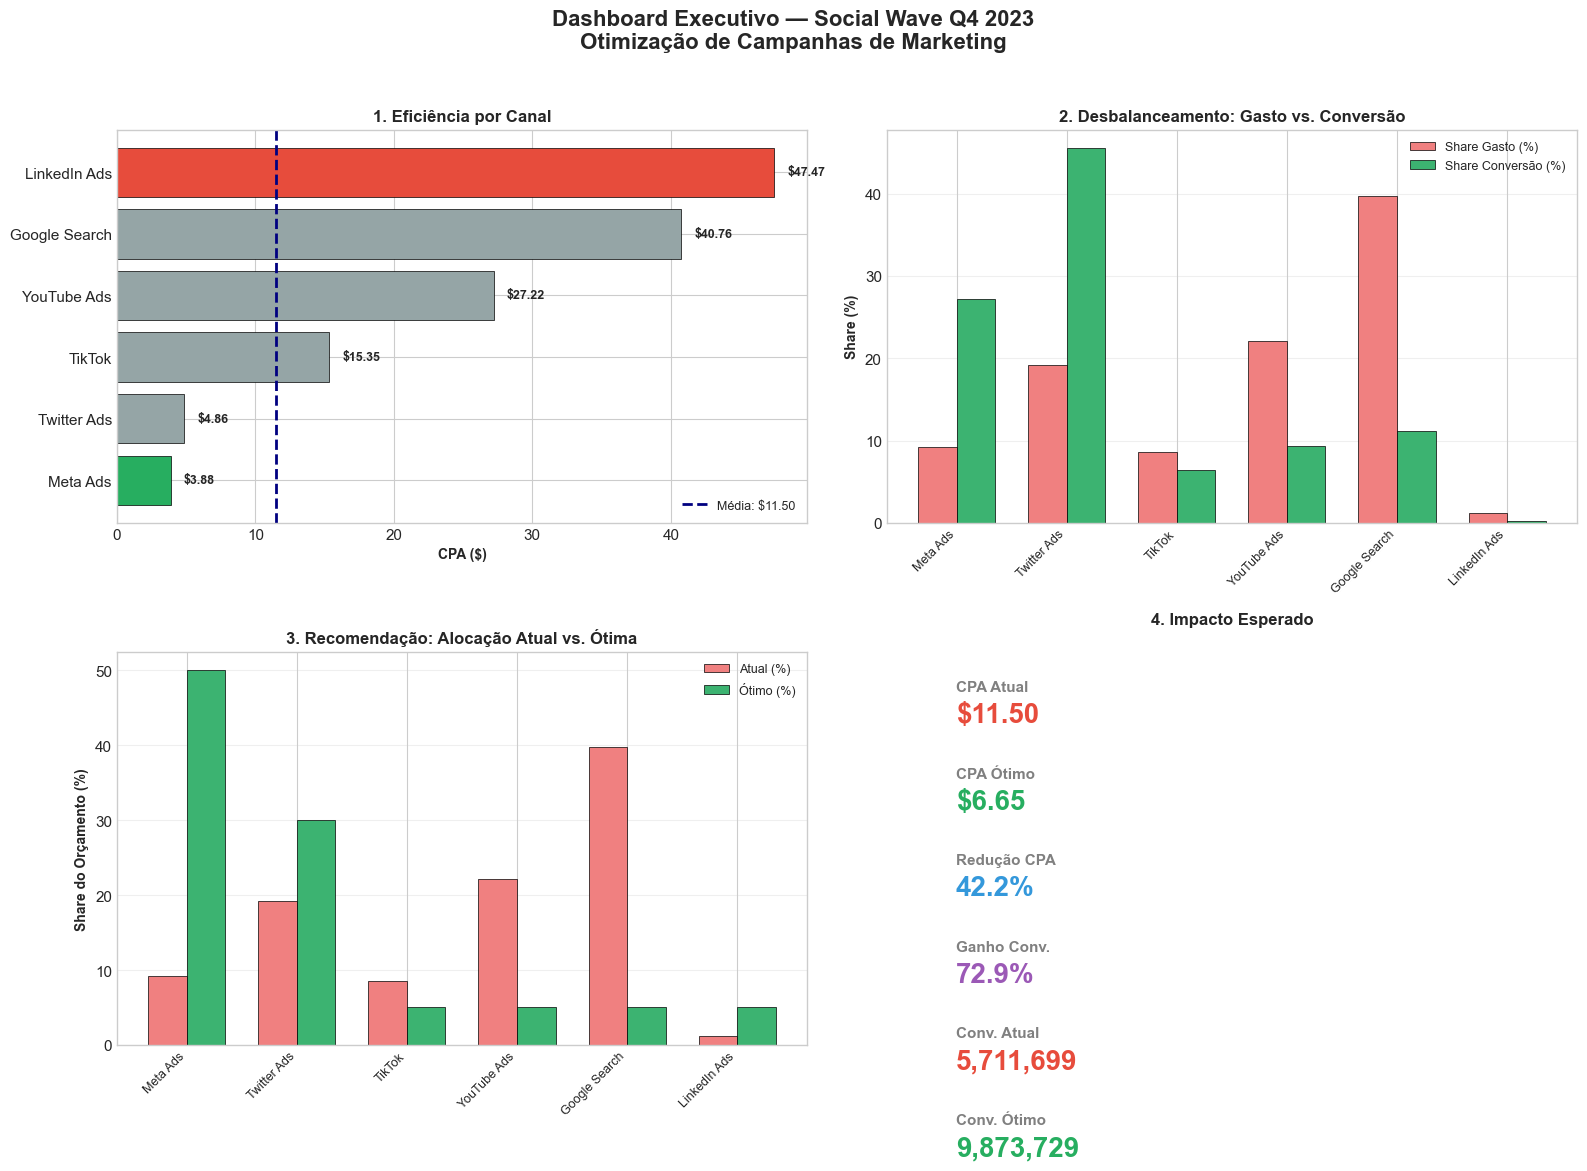


🚀 DASHBOARD EXECUTIVO COMPLETO!


In [6]:
print('=' * 60)
print('📊 DASHBOARD EXECUTIVO')
print('=' * 60)

# ============================================================
# PREPARAR DADOS
# ============================================================

# Ranking por CPA
resumo_rank = resumo.sort_values('CPA')
canais_rank = resumo_rank.index.tolist()
cpa_rank = resumo_rank['CPA'].values

# Shares
share_gasto = resumo['Share_Gasto'].values
share_conv = resumo['Share_Conversao'].values

# Alocação ótima vs. atual
otimo_pct = share_otimo * 100
atual_pct = share_atual * 100

# ============================================================
# CRIAR FIGURA COM 4 SUBPLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Dashboard Executivo — Social Wave Q4 2023\nOtimização de Campanhas de Marketing',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

# --- Gráfico 1: CPA por Canal (barras horizontais) ---
ax1 = axes[0, 0]
cores1 = ['#27ae60' if c == canal_top else '#e74c3c' if c == canal_bottom else '#95a5a6' for c in canais_rank]
barras1 = ax1.barh(canais_rank, cpa_rank, color=cores1, edgecolor='black', linewidth=0.5)
ax1.axvline(x=cpa_global, color='navy', linestyle='--', linewidth=2, label=f'Média: ${cpa_global:.2f}')
ax1.set_xlabel('CPA ($)', fontsize=10, fontweight='bold')
ax1.set_title('1. Eficiência por Canal', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

for i, (bar, val) in enumerate(zip(barras1, cpa_rank)):
    ax1.text(val + (cpa_rank.max() * 0.02), bar.get_y() + bar.get_height()/2, f'${val:.2f}', va='center', fontsize=9, fontweight='bold')

# --- Gráfico 2: Desbalanceamento (gasto vs. conversão) ---
ax2 = axes[0, 1]
x2 = np.arange(len(canais))
largura = 0.35
ax2.bar(x2 - largura/2, share_gasto, largura, label='Share Gasto (%)', color='lightcoral', edgecolor='black', linewidth=0.5)
ax2.bar(x2 + largura/2, share_conv, largura, label='Share Conversão (%)', color='mediumseagreen', edgecolor='black', linewidth=0.5)
ax2.set_xticks(x2)
ax2.set_xticklabels(canais, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Share (%)', fontsize=10, fontweight='bold')
ax2.set_title('2. Desbalanceamento: Gasto vs. Conversão', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# --- Gráfico 3: Alocação Atual vs. Ótima ---
ax3 = axes[1, 0]
x3 = np.arange(len(canais))
largura3 = 0.35
ax3.bar(x3 - largura3/2, atual_pct, largura3, label='Atual (%)', color='lightcoral', edgecolor='black', linewidth=0.5)
ax3.bar(x3 + largura3/2, otimo_pct, largura3, label='Ótimo (%)', color='mediumseagreen', edgecolor='black', linewidth=0.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(canais, rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Share do Orçamento (%)', fontsize=10, fontweight='bold')
ax3.set_title('3. Recomendação: Alocação Atual vs. Ótima', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# --- Gráfico 4: Impacto Esperado (KPIs) ---
ax4 = axes[1, 1]
ax4.axis('off')

# KPIs em formato de cards
kpis = [
    ('CPA Atual', f'${cpa_global:.2f}', '#e74c3c'),
    ('CPA Ótimo', f'${cpa_global_otimo:.2f}', '#27ae60'),
    ('Redução CPA', f'{reducao_cpa_pct:.1f}%', '#3498db'),
    ('Ganho Conv.', f'{ganho_conv_pct:.1f}%', '#9b59b6'),
    ('Conv. Atual', f'{conversao_total:,.0f}', '#e74c3c'),
    ('Conv. Ótimo', f'{conversoes_total_otimo:,.0f}', '#27ae60')
]

y_pos = 0.9
for label, valor, cor in kpis:
    ax4.text(0.1, y_pos, label, fontsize=11, fontweight='bold', color='gray')
    ax4.text(0.1, y_pos - 0.08, valor, fontsize=20, fontweight='bold', color=cor)
    y_pos -= 0.22

ax4.set_title('4. Impacto Esperado', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ============================================================
# SALVAR FIGURA
# ============================================================

figura_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\12_dashboard_executivo.png'
plt.savefig(figura_path, dpi=150, bbox_inches='tight')
print(f'✅ Dashboard salvo: {figura_path}')

# ============================================================
# EXIBIR
# ============================================================

plt.show()

print('\n' + '=' * 60)
print('🚀 DASHBOARD EXECUTIVO COMPLETO!')
print('=' * 60)

| Posição            | Gráfico          | Função                              |
| ------------------ | ---------------- | ----------------------------------- |
| **Topo-esquerdo**  | CPA por canal    | Mostrar o problema (eficiência)     |
| **Topo-direito**   | Desbalanceamento | Mostrar a causa (gasto ≠ conversão) |
| **Fundo-esquerdo** | Atual vs. Ótima  | Mostrar a solução (recomendação)    |
| **Fundo-direito**  | KPIs             | Mostrar o impacto (ganho esperado)  |


## Resumo Final e Encerramento

Consolidação de todos os entregáveis do projeto, salva o resumo final e encerra o Notebook 04. 

É o "fechamento" do projeto — checklist de tudo que foi produzido.

In [7]:
print('=' * 70)
print('🎉 PROJETO SOCIAL WAVE — CONCLUSÃO')
print('=' * 70)

# ============================================================
# ENTREGÁVEIS PRODUZIDOS
# ============================================================

print('\n' + '-' * 70)
print('ENTREGÁVEIS PRODUZIDOS')
print('-' * 70)

entregaveis = {
    'Notebooks': [
        '00_contexto_e_dicionario.ipynb — Contexto e validação de dados',
        '01_exploratory_analysis.ipynb — Análise exploratória (EDA)',
        '02_cpa_analysis.ipynb — Decomposição e análise de sensibilidade',
        '03_budget_optimization.ipynb — Modelo de otimização de orçamento',
        '04_executive_summary.ipynb — Resumo executivo e storytelling'
    ],
    'Dados Processados': [
        'data/processed/campanhas_limpo.pkl — Base tratada',
        'data/processed/resumo_por_canal.pkl — Resumo agregado'
    ],
    'Relatórios': [
        'reports/resumo_executivo_eda.txt — Resumo do EDA',
        'reports/resumo_analise_cpa.txt — Resumo da análise de CPA',
        'reports/resumo_otimizacao.txt — Resumo da otimização'
    ],
    'Figuras': [
        'reports/figures/01_cpa_por_canal.png',
        'reports/figures/02_share_gasto_vs_conversao.png',
        'reports/figures/03_gasto_vs_cpa_scatter.png',
        'reports/figures/04_evolucao_cpa_temporal.png',
        'reports/figures/05_ctr_vs_taxa_conversao.png',
        'reports/figures/06_matriz_correlacao.png',
        'reports/figures/07_decomposicao_cpa.png',
        'reports/figures/08_tornado_sensibilidade.png',
        'reports/figures/09_alocacao_atual_vs_otima.png',
        'reports/figures/10_tradeoff_custo_volume.png',
        'reports/figures/11_simulacao_aumento_20pct.png',
        'reports/figures/12_dashboard_executivo.png'
    ]
}

for categoria, itens in entregaveis.items():
    print(f'\n📁 {categoria}:')
    for item in itens:
        print(f'   • {item}')

# ============================================================
# MÉTRICAS FINAl DO PROJETO
# ============================================================

print('\n' + '-' * 70)
print('MÉTRICAS FINAIS DO PROJETO')
print('-' * 70)

print(f'''
📊 BASE ANALISADA:
   • Período: Outubro a Dezembro de 2023
   • Registros: {df.shape[0]:,}
   • Canais: 6 (Meta, Google, YouTube, Twitter, TikTok, LinkedIn)
   • Gasto total: ${gasto_total:,.2f}
   • Conversões: {conversao_total:,.0f}

🏆 PRINCIPAIS ACHADOS:
   • Canal mais eficiente: {canal_top} (CPA ${cpa_top:.2f})
   • Canal menos eficiente: {canal_bottom} (CPA ${cpa_bottom:.2f})
   • Diferença de eficiência: {cpa_bottom/cpa_top:.1f}x

🎯 RECOMENDAÇÃO CENTRAL:
   • Reduzir verba em: {canal_bottom} e canais sobre-investidos
   • Aumentar verba em: {canal_top} e canais sub-investidos
   • Manter presença mínima de 5% em todos os canais

📈 IMPACTO ESPERADO:
   • CPA global: ${cpa_global:.2f} → ${cpa_global_otimo:.2f}
   • Redução de CPA: {reducao_cpa_pct:.1f}%
   • Ganho de conversões: {ganho_conv_pct:.1f}%
   • Conversões a mais: {conversoes_total_otimo - conversao_total:,.0f}
''')

# ============================================================
# PRÓXIMOS PASSOS SUGERIDOS
# ============================================================

print('\n' + '-' * 70)
print('3. PRÓXIMOS PASSOS SUGERIDOS')
print('-' * 70)

print('''
🔜 IMPLEMENTAÇÃO:
   1. Semana 1-2: Realocar 25% da recomendação (fase conservador)
   2. Semana 3-4: Realocar 50% (fase moderado)
   3. Semana 5-6: Aplicar 100% (fase agressivo)
   4. Semana 7+: Monitorar e ajustar trimestralmente

🔜 EXPANSÕES DO PROJETO:
   • Adicionar dados de Janeiro-Março 2024 para validar modelo
   • Incorporar sazonalidade (Black Friday, Natal, etc.)
   • Desenvolver modelo preditivo de CPA (machine learning)
   • Automatizar relatório semanal com atualização de dados

🔜 POWER BI (opcional):
   • Dashboard interativo com filtros por canal e período
   • KPI cards com atualização em tempo real
   • Simulador de cenários (what-if)
''')

# ============================================================
# SALVAR RESUMO FINAL
# ============================================================

print('\n' + '-' * 70)
print('4. SALVAR RESUMO FINAL')
print('-' * 70)

resumo_final = f'''================================================================
RESUMO FINAL — PROJETO SOCIAL WAVE
Gerado em: {datetime.now().strftime('%Y-%m-%d %H:%M')}
================================================================

1. CONTEXTO
   Empresa: Social Wave (marketing digital)
   Problema: CPA disparou após aumento igualitário de verba
   Período analisado: Out-Dez 2023
   Stack: Python (Pandas, Matplotlib, SciPy) + Jupyter

2. METODOLOGIA
   • Notebook 01: EDA — diagnóstico do problema
   • Notebook 02: Análise de CPA — decomposição em componentes
   • Notebook 03: Otimização — modelo de alocação ótima
   • Notebook 04: Resumo executivo — storytelling para gestores

3. RESULTADOS
   CPA atual: ${cpa_global:.2f}
   CPA ótimo: ${cpa_global_otimo:.2f}
   Redução: {reducao_cpa_pct:.1f}%
   Conversões: {conversao_total:.0f} → {conversoes_total_otimo:.0f}

4. RECOMENDAÇÃO
   Realocar verba de canais ineficientes para eficientes,
   respeitando presença mínima de 5% em cada canal.

5. ENTREGÁVEIS
   5 notebooks, 2 arquivos de dados, 3 relatórios de texto,
   12 figuras, 1 dashboard executivo.

================================================================
'''

resumo_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_final_projeto.txt'
with open(resumo_path, 'w', encoding='utf-8') as f:
    f.write(resumo_final)

print(f'✅ Resumo final salvo: {resumo_path}')

# ============================================================
# 5. EXIBIR RESUMO
# ============================================================

print('\n' + '=' * 70)
print('📄 RESUMO FINAL')
print('=' * 70)
print(resumo_final)

# ============================================================
# 6. ENCERRAMENTO
# ============================================================

print('\n' + '=' * 70)
print('🎉 PROJETO CONCLUÍDO COM SUCESSO!')
print('=' * 70)

print(f'''
📊 Estatísticas do projeto:
   • 5 notebooks executados
   • 12 visualizações geradas
   • 3 relatórios de texto salvos
   • 1 modelo de otimização construído

🏆 Obrigado por acompanhar este projeto do início ao fim!
   Desde a validação de dados até a recomendação executiva,
   cada etapa foi documentada e reproduzível.

🚀 Próximo passo: Implementar a recomendação e monitorar resultados!
''')

print('=' * 70)

🎉 PROJETO SOCIAL WAVE — CONCLUSÃO

----------------------------------------------------------------------
ENTREGÁVEIS PRODUZIDOS
----------------------------------------------------------------------

📁 Notebooks:
   • 00_contexto_e_dicionario.ipynb — Contexto e validação de dados
   • 01_exploratory_analysis.ipynb — Análise exploratória (EDA)
   • 02_cpa_analysis.ipynb — Decomposição e análise de sensibilidade
   • 03_budget_optimization.ipynb — Modelo de otimização de orçamento
   • 04_executive_summary.ipynb — Resumo executivo e storytelling

📁 Dados Processados:
   • data/processed/campanhas_limpo.pkl — Base tratada
   • data/processed/resumo_por_canal.pkl — Resumo agregado

📁 Relatórios:
   • reports/resumo_executivo_eda.txt — Resumo do EDA
   • reports/resumo_analise_cpa.txt — Resumo da análise de CPA
   • reports/resumo_otimizacao.txt — Resumo da otimização

📁 Figuras:
   • reports/figures/01_cpa_por_canal.png
   • reports/figures/02_share_gasto_vs_conversao.png
   • reports/fig